In [1]:
# check for any samples wtih any genomic oddities in POLD1 or MSI genes
# and the relationship to SBS_D 

In [2]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

In [4]:
acts = pd.read_csv('/Users/kazachkova/Documents/tscc/projects/mutographs/CRC/V3_data/pruned_attribution_CRC_Manuscript_denovo_SBS288_abs_mutations.csv',index_col=0)



IDs = pd.read_csv('/Users/kazachkova/Documents/alexandrov_lab/mutographs/CRC_clonal_analysis/V3_Data/examine_SBS288D/plots_for_paper/Supplementary_Table2.csv',
                 index_col=0)

snvs = pd.read_csv('/Users/kazachkova/Documents/alexandrov_lab/mutographs/CRC_clonal_analysis/V3_Data/examine_SBS288D/plots_for_paper/Supplementary_Table1.csv',
                 index_col=0)


In [5]:
acts_for_ID = acts.copy()
acts_for_SNV = acts.copy()

IDs['SBS288D'] = acts.loc[:,'SBS288D']
snvs['SBS288D'] = acts.loc[:,'SBS288D']

rest_IDs = acts.loc[set(acts.index) - set(IDs.index)]
rest_SNVs = acts.loc[set(acts.index) - set(snvs.index)]

/var/folders/hm/tm8gk7s95dz827sk5fljrj2r0000gn/T/ipykernel_89462/3719066282.py:7: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  rest_IDs = acts.loc[set(acts.index) - set(IDs.index)]
/var/folders/hm/tm8gk7s95dz827sk5fljrj2r0000gn/T/ipykernel_89462/3719066282.py:8: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  rest_SNVs = acts.loc[set(acts.index) - set(snvs.index)]


In [6]:
from collections import Counter
from scipy import stats

In [7]:
ID_pold1 = IDs[IDs.loc[:,'Hugo_Symbol'] == 'POLD1']

SNV_pold1 = snvs[snvs.loc[:,'Hugo_Symbol'] == 'POLD1']

Missense
(n=9)
MannwhitneyuResult(statistic=3868.0, pvalue=0.6375595121091061)


/var/folders/hm/tm8gk7s95dz827sk5fljrj2r0000gn/T/ipykernel_89462/3123925118.py:6: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  rest_SNVs = acts.loc[set(acts.index) - set(SNVs_.index)]


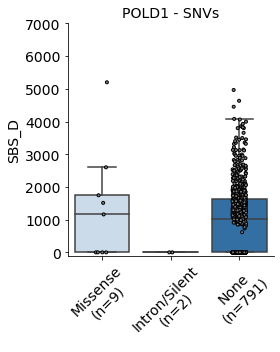

In [11]:
######## PANEL A ##########


SNVs_ = SNV_pold1.loc[:,['Variant_Classification','SBS288D']].copy()

rest_SNVs = acts.loc[set(acts.index) - set(SNVs_.index)]

snv_rest_df = pd.DataFrame(rest_SNVs.loc[:,'SBS288D'])
snv_rest_df['Variant_Classification'] = 'None'


SNVs_all = pd.concat([SNVs_,snv_rest_df])

SNVs_all.loc[:,'Variant_Classification'] = SNVs_all.loc[:,'Variant_Classification'].str.replace('_Mutation','')
SNVs_all.loc[:,'Variant_Classification'] = SNVs_all.loc[:,'Variant_Classification'].str.replace('Silent','SS')
SNVs_all.loc[:,'Variant_Classification'] = SNVs_all.loc[:,'Variant_Classification'].str.replace('Intron','Intron/Silent')
SNVs_all.loc[:,'Variant_Classification'] = SNVs_all.loc[:,'Variant_Classification'].str.replace('SS','Intron/Silent')


SNVs_all.index = SNVs_all.index + SNVs_all.loc[:,'Variant_Classification']
SNVs_all=SNVs_all[~SNVs_all.index.duplicated()]


# add Ns
to_add_ns = pd.Series(Counter(SNVs_all.loc[:,'Variant_Classification']))
SNVs_all.loc[:,'Variant_Classification'] = SNVs_all.loc[:,'Variant_Classification'] + '\n(n=' +  to_add_ns.loc[SNVs_all.loc[:,'Variant_Classification']].astype(str).values + ')'




fig,ax = plt.subplots(figsize=(4,5))

sns.boxplot(data=SNVs_all,
           x='Variant_Classification',y='SBS288D',fliersize=0,palette='Blues')
sns.stripplot(data=SNVs_all,
           x='Variant_Classification',y='SBS288D',color='grey',edgecolor='black',s=3,
             linewidth=1)

plt.xticks(rotation=45)
plt.ylabel('SBS_D')

for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(14)
plt.xlabel('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)



# add_stat_annotation(ax, data=SNVs_all, x='Variant_Classification', y='SBS288D',
#                     box_pairs=[("None", "Nonsense"),
#                               ("None", "Nonsense"),
#                               ("None", "Missense"),
#                               ("None", "Intron"),
#                               ("None", "Silent"),
                             
                              
                               
#                               ],
#                     test='Mann-Whitney', text_format='star', loc='inside', verbose=2,
#                    )


plt.title('POLD1 - SNVs',fontsize=14)
ax.set_ylim(-100,7000)

plt.tight_layout()

# plt.savefig('plots_for_paper/POLD1_SNVs.png',dpi=300)


counts = pd.Series(Counter(SNVs_all.loc[:,'Variant_Classification']))

for c in counts.index:
    if counts.loc[c] <= 5 or 'None' in c:
        continue
    print(c)
    print(stats.mannwhitneyu(SNVs_all[SNVs_all.loc[:,'Variant_Classification'] == c].loc[:,'SBS288D'],
                      SNVs_all[SNVs_all.loc[:,'Variant_Classification'].str.contains('None')].loc[:,'SBS288D']))

/var/folders/hm/tm8gk7s95dz827sk5fljrj2r0000gn/T/ipykernel_89462/959168474.py:5: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  rest_IDs = acts.loc[set(acts.index) - set(IDs_.index)]


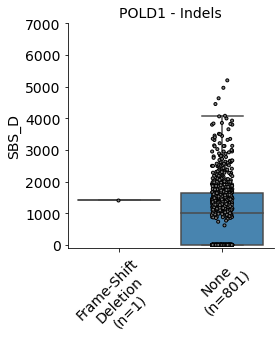

In [12]:

####### PANEL A cont #########

IDs_ = ID_pold1.loc[:,['Variant_Classification','SBS288D']].copy()

rest_IDs = acts.loc[set(acts.index) - set(IDs_.index)]

ID_rest_df = pd.DataFrame(rest_IDs.loc[:,'SBS288D'])
ID_rest_df['Variant_Classification'] = 'None'


IDs_all = pd.concat([IDs_,ID_rest_df])

IDs_all.loc[:,'Variant_Classification'] = IDs_all.loc[:,'Variant_Classification'].str.replace('Frame_Shift','Frame-Shift').str.replace('In_Frame','In-Frame')
IDs_all.loc[:,'Variant_Classification'] = IDs_all.loc[:,'Variant_Classification'].str.replace('_','\n')
IDs_all.loc[:,'Variant_Classification'] = IDs_all.loc[:,'Variant_Classification'].str.replace('Ins','Insertion')
IDs_all.loc[:,'Variant_Classification'] = IDs_all.loc[:,'Variant_Classification'].str.replace('Del','Deletion')


IDs_all.index = IDs_all.index + IDs_all.loc[:,'Variant_Classification']
IDs_all=IDs_all[~IDs_all.index.duplicated()]



# add Ns
to_add_ns = pd.Series(Counter(IDs_all.loc[:,'Variant_Classification']))
IDs_all.loc[:,'Variant_Classification'] = IDs_all.loc[:,'Variant_Classification'] + '\n(n=' +  to_add_ns.loc[IDs_all.loc[:,'Variant_Classification']].astype(str).values + ')'



fig,ax = plt.subplots(figsize=(4,5))

sns.boxplot(data=IDs_all,
           x='Variant_Classification',y='SBS288D',fliersize=0,palette='Blues')
sns.stripplot(data=IDs_all,
           x='Variant_Classification',y='SBS288D',color='grey',edgecolor='black',s=3,
             linewidth=1)

plt.xticks(rotation=45)
plt.ylabel('SBS_D')

for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(14)
plt.xlabel('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)



# add_stat_annotation(ax, data=IDs_all, x='Variant_Classification', y='SBS288D',
#                     box_pairs=[("None", "Nonsense"),
#                               ("None", "Nonsense"),
#                               ("None", "Missense"),
#                               ("None", "Intron"),
#                               ("None", "Silent"),
                             
                              
                               
#                               ],
#                     test='Mann-Whitney', text_format='star', loc='inside', verbose=2,
#                    )


plt.title('POLD1 - Indels',fontsize=14)
plt.ylim(-100,7000)
plt.tight_layout()

# plt.savefig('plots_for_paper/POLD1_IDs.png',dpi=300)


counts = pd.Series(Counter(IDs_all.loc[:,'Variant_Classification']))

for c in counts.index:
    if counts.loc[c] <= 5 or 'None' in c:
        continue
    print(c)
    print(stats.mannwhitneyu(IDs_all[IDs_all.loc[:,'Variant_Classification'] == c].loc[:,'SBS288D'],
                      IDs_all[IDs_all.loc[:,'Variant_Classification'].str.contains('None')].loc[:,'SBS288D']))
    

In [13]:
to_add_ns = pd.Series(Counter(IDs_all.loc[:,'Variant_Classification']))
IDs_all.loc[:,'Variant_Classification'] + '\n(n=' +  to_add_ns.loc[IDs_all.loc[:,'Variant_Classification']].astype(str).values + ')'


PD54872aFrame-Shift\nDeletion    Frame-Shift\nDeletion\n(n=1)\n(n=1)
PD47148aNone                                  None\n(n=801)\n(n=801)
PD47069aNone                                  None\n(n=801)\n(n=801)
PD52576aNone                                  None\n(n=801)\n(n=801)
PD55064aNone                                  None\n(n=801)\n(n=801)
                                                ...                 
PD55487aNone                                  None\n(n=801)\n(n=801)
PD47071aNone                                  None\n(n=801)\n(n=801)
PD52157aNone                                  None\n(n=801)\n(n=801)
PD52052aNone                                  None\n(n=801)\n(n=801)
PD47153aNone                                  None\n(n=801)\n(n=801)
Name: Variant_Classification, Length: 802, dtype: object

Missense
(n=21)
MannwhitneyuResult(statistic=8963.0, pvalue=0.36974662433818184)
Intron/Silent
(n=21)
MannwhitneyuResult(statistic=9825.5, pvalue=0.07544669796152971)


/var/folders/hm/tm8gk7s95dz827sk5fljrj2r0000gn/T/ipykernel_89462/124923838.py:10: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  rest_SNVs = acts.loc[set(acts.index) - set(SNVs_.index)]


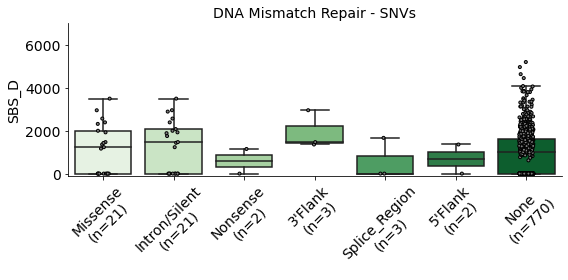

In [14]:
# same thing for DNA mismatch repair genes 

##### PANEL B ##########


SNV_not_pold1 = snvs[snvs.loc[:,'Hugo_Symbol'] != 'POLD1']

SNVs_ = SNV_not_pold1.loc[:,['Variant_Classification','SBS288D']].copy()

rest_SNVs = acts.loc[set(acts.index) - set(SNVs_.index)]

snv_rest_df = pd.DataFrame(rest_SNVs.loc[:,'SBS288D'])
snv_rest_df['Variant_Classification'] = 'None'


SNVs_all = pd.concat([SNVs_,snv_rest_df])

SNVs_all.loc[:,'Variant_Classification'] = SNVs_all.loc[:,'Variant_Classification'].str.replace('_Mutation','')
SNVs_all.loc[:,'Variant_Classification'] = SNVs_all.loc[:,'Variant_Classification'].str.replace('Silent','SS')
SNVs_all.loc[:,'Variant_Classification'] = SNVs_all.loc[:,'Variant_Classification'].str.replace('Intron','Intron/Silent')
SNVs_all.loc[:,'Variant_Classification'] = SNVs_all.loc[:,'Variant_Classification'].str.replace('SS','Intron/Silent')


SNVs_all.index = SNVs_all.index + SNVs_all.loc[:,'Variant_Classification']
SNVs_all=SNVs_all[~SNVs_all.index.duplicated()]

to_add_ns = pd.Series(Counter(SNVs_all.loc[:,'Variant_Classification']))
SNVs_all.loc[:,'Variant_Classification'] = SNVs_all.loc[:,'Variant_Classification'] + '\n(n=' +  to_add_ns.loc[SNVs_all.loc[:,'Variant_Classification']].astype(str).values + ')'



fig,ax = plt.subplots(figsize=(8,4))

sns.boxplot(data=SNVs_all,
           x='Variant_Classification',y='SBS288D',fliersize=0,palette='Greens')
sns.stripplot(data=SNVs_all,
           x='Variant_Classification',y='SBS288D',color='grey',edgecolor='black',s=3,
             linewidth=1)

plt.xticks(rotation=45)
plt.ylabel('SBS_D')

for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(14)
plt.xlabel('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)



# add_stat_annotation(ax, data=SNVs_all, x='Variant_Classification', y='SBS288D',
#                     box_pairs=[("None", "Nonsense"),
#                               ("None", "Nonsense"),
#                               ("None", "Missense"),
#                               ("None", "Intron"),
#                               ("None", "Silent"),
                             
                              
                               
#                               ],
#                     test='Mann-Whitney', text_format='star', loc='inside', verbose=2,
#                    )


plt.title('DNA Mismatch Repair - SNVs',fontsize=14)

plt.ylim(-100,7000)
plt.tight_layout()

# plt.savefig('plots_for_paper/mismatch_repair_SNVs.png',dpi=300)



counts = pd.Series(Counter(SNVs_all.loc[:,'Variant_Classification']))

for c in counts.index:
    if counts.loc[c] <= 5 or 'None' in c:
        continue
    print(c)
    print(stats.mannwhitneyu(SNVs_all[SNVs_all.loc[:,'Variant_Classification'] == c].loc[:,'SBS288D'],
                      SNVs_all[SNVs_all.loc[:,'Variant_Classification'].str.contains('None')].loc[:,'SBS288D']))
    


In [15]:
indel_acts = pd.read_csv('/Users/kazachkova/Documents/tscc/restricted/mutographs/checking_SBS288D_other_tissues/other_mutation_types_CRC/ID83/output_tables/pruned_attribution_CRC_Manuscript_COSMIC_ID83_abs_mutations.csv',
                      index_col=0)

/var/folders/hm/tm8gk7s95dz827sk5fljrj2r0000gn/T/ipykernel_89462/1327550168.py:10: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  rest_IDs = acts.loc[set(acts.index) - set(IDs_.index)]


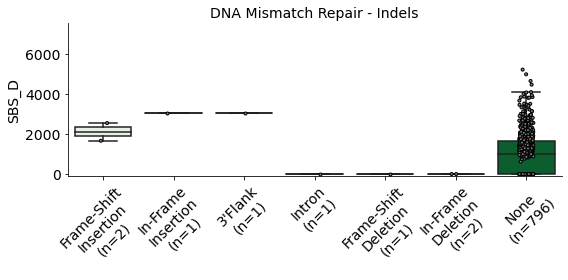

In [17]:
# same thing for DNA mismatch repair genes 

####### PANEL B cont #######


ID_not_pold1 = IDs[IDs.loc[:,'Hugo_Symbol'] != 'POLD1']

IDs_ = ID_not_pold1.loc[:,['Variant_Classification','SBS288D']].copy()

rest_IDs = acts.loc[set(acts.index) - set(IDs_.index)]

ID_rest_df = pd.DataFrame(rest_IDs.loc[:,'SBS288D'])
ID_rest_df['Variant_Classification'] = 'None'


IDs_all = pd.concat([IDs_,ID_rest_df])

# IDs_all['total_indels'] = indel_acts.sum(axis=1)

IDs_all.loc[:,'Variant_Classification'] = IDs_all.loc[:,'Variant_Classification'].str.replace('Frame_Shift','Frame-Shift').str.replace('In_Frame','In-Frame')
IDs_all.loc[:,'Variant_Classification'] = IDs_all.loc[:,'Variant_Classification'].str.replace('_','\n')
IDs_all.loc[:,'Variant_Classification'] = IDs_all.loc[:,'Variant_Classification'].str.replace('Ins','Insertion')
IDs_all.loc[:,'Variant_Classification'] = IDs_all.loc[:,'Variant_Classification'].str.replace('Del','Deletion')



# IDs_all.loc[:,'Variant_Classification'] = IDs_all.loc[:,'Variant_Classification'].str.replace('Frame-Shift\nInsertion','Frame-Shift\nInDel')
# IDs_all.loc[:,'Variant_Classification'] = IDs_all.loc[:,'Variant_Classification'].str.replace('Frame-Shift\nDeletion','Frame-Shift\nInDel')

# IDs_all.loc[:,'Variant_Classification'] = IDs_all.loc[:,'Variant_Classification'].str.replace('In-Frame\nInsertion','In-Frame\nInDel')
# IDs_all.loc[:,'Variant_Classification'] = IDs_all.loc[:,'Variant_Classification'].str.replace('In-Frame\nDeletion','In-Frame\nInDel')


# IDs_all.loc[:,'Variant_Classification'] = IDs_all.loc[:,'Variant_Classification'].str.replace('Intron','Intron/regulatory')
# IDs_all.loc[:,'Variant_Classification'] = IDs_all.loc[:,'Variant_Classification'].str.replace('3\'Flank','Intron/regulatory')
# IDs_all.loc[:,'Variant_Classification'] = IDs_all.loc[:,'Variant_Classification'].str.replace('3\'UTR','Intron/regulatory')
# IDs_all.loc[:,'Variant_Classification'] = IDs_all.loc[:,'Variant_Classification'].str.replace('5\'Flank','Intron/regulatory')


IDs_all.index = IDs_all.index + IDs_all.loc[:,'Variant_Classification']
IDs_all=IDs_all[~IDs_all.index.duplicated()]


# add Ns
to_add_ns = pd.Series(Counter(IDs_all.loc[:,'Variant_Classification']))
IDs_all.loc[:,'Variant_Classification'] = IDs_all.loc[:,'Variant_Classification'] + '\n(n=' +  to_add_ns.loc[IDs_all.loc[:,'Variant_Classification']].astype(str).values + ')'


fig,ax = plt.subplots(figsize=(8,4))

sns.boxplot(data=IDs_all,
           x='Variant_Classification',y='SBS288D',fliersize=0,palette='Greens')
sns.stripplot(data=IDs_all,
           x='Variant_Classification',y='SBS288D',color='grey',edgecolor='black',s=3,
             linewidth=1)

plt.xticks(rotation=45)
plt.ylabel('SBS_D')

for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(14)
plt.xlabel('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)



# add_stat_annotation(ax, data=IDs_all, x='Variant_Classification', y='SBS288D',
#                     box_pairs=[("None", "Nonsense"),
#                               ("None", "Nonsense"),
#                               ("None", "Missense"),
#                               ("None", "Intron"),
#                               ("None", "Silent"),
                             
                              
                               
#                               ],
#                     test='Mann-Whitney', text_format='star', loc='inside', verbose=2,
#                    )

plt.ylim(-100,7500)
plt.title('DNA Mismatch Repair - Indels',fontsize=14)

plt.tight_layout()

# plt.savefig('plots_for_paper/mismatch_repair_IDs.png',dpi=300)



import numpy as np
counts = pd.Series(Counter(IDs_all.loc[:,'Variant_Classification']))

for c in counts.index:
    if counts.loc[c] <= 5 or 'None' in c:
        continue
    print(c)
    print(stats.mannwhitneyu(IDs_all[IDs_all.loc[:,'Variant_Classification'] == c].loc[:,'SBS288D'],
                      IDs_all[IDs_all.loc[:,'Variant_Classification'].str.contains('None')].loc[:,'SBS288D']))
# print(len(IDs_all[IDs_all.loc[:,'Variant_Classification'] == 'Intron'].loc[:,'SBS288D']))
# print(len(IDs_all[IDs_all.loc[:,'Variant_Classification'] == '3\'Flank'].loc[:,'SBS288D']))
# print(len(IDs_all[IDs_all.loc[:,'Variant_Classification'] == '3\'UTR'].loc[:,'SBS288D']))
# print(len(IDs_all[IDs_all.loc[:,'Variant_Classification'] == '5\'Flank'].loc[:,'SBS288D']))
# print(len(IDs_all[IDs_all.loc[:,'Variant_Classification'] == 'Frame-Shift Insertion'].loc[:,'SBS288D']))
# print(len(IDs_all[IDs_all.loc[:,'Variant_Classification'] == 'Frame-Shift Deletion'].loc[:,'SBS288D']))
# print(len(IDs_all[IDs_all.loc[:,'Variant_Classification'] == 'In-Frame Deletion'].loc[:,'SBS288D']))
# print(len(IDs_all[IDs_all.loc[:,'Variant_Classification'] == 'In-Frame Insertion'].loc[:,'SBS288D']))

# print(len(IDs_all[IDs_all.loc[:,'Variant_Classification'] == 'None'].loc[:,'SBS288D']))
    



In [18]:
# now we want to look at LOH 

In [19]:
# amps = pd.read_table('/Users/kazachkova/Documents/alexandrov_lab/mutographs/CRC_clonal_analysis/V3_Data/meat_analysis2/driver_CN/amp-matrix.txt',index_col=0).T
# loh = pd.read_table('/Users/kazachkova/Documents/alexandrov_lab/mutographs/CRC_clonal_analysis/V3_Data/meat_analysis2/driver_CN/loh-matrix-cancers.txt',index_col=0).T

# amps['SBS288D'] = acts.loc[:,'SBS288D']
# loh['SBS288D'] = acts.loc[:,'SBS288D']

# amps=amps.dropna()
# loh=loh.dropna()

In [20]:
marcos_drivers =  pd.read_table('/Users/kazachkova/Documents/tscc/restricted/mutographs/CRC/Metadata_TMB_Signatures_SBS_ID_DBS_CN_SV_Drivers_2024AUG21.tsv',
             index_col=0)

In [21]:
# will need to iterate over the battenberg files and check for the locations.
# need to get the location of POLD1 and the other genes

import os

to_check = ['MLH1', 'MLH3', 'MSH2', 'MSH3', 'MSH6', 'PMS1', 'PMS2']

pold1 = ['chr19',50384323,50418018]
MLH1 = ['chr3',36993548,37050653]
MLH3 =  ['chr14',75013775,75051467]
MSH2 = ['chr2',47630295,47710362]
MSH3 = ['chr7',155799529,155812871]
MSH6 =  ['chr2',47783585,47806953]
PMS1 = ['chr2',189784450,189877629]
PMS2 = ['chr7',5973399,6009042]
  
gene_dic = {'POLD1':pold1,
           'MLH1':MLH1,
           'MLH3':MLH3,
           'MSH2':MSH2,
           'MSH3':MSH3,
           'MSH6':MSH6,
           'PMS1':PMS1,
           'PMS2':PMS2}
    
fin_loh_df = pd.DataFrame(columns = ['sample','gene'])
    
#somehow we need to check all of those locations for each battenberg file 

i = 0
for sample in acts.index:
    if not os.path.exists('/Users/kazachkova/Documents/tscc/restricted/mutographs/CRC/V3_data/battenberg/' + sample + '.battenberg.subclones.txt'):
                          continue
    
    cn = pd.read_table('/Users/kazachkova/Documents/tscc/restricted/mutographs/CRC/V3_data/battenberg/' + sample + '.battenberg.subclones.txt')
    
    for gene in gene_dic.keys():
        g = gene
        chrr = gene_dic[gene][0]
        startt = int(gene_dic[gene][1])
        endd = int(gene_dic[gene][2])
        
        temp = cn[cn.loc[:,'chr'] == chrr]
        zeros = temp[(temp.loc[:,'nMin1_A'] == 0) | 
                (temp.loc[:,'nMin2_A'] == 0)]
        
        if zeros.shape[0] != 0:
            filtered = zeros[(zeros.loc[:,'startpos'] < startt) & 
                            (zeros.loc[:,'endpos'] > endd)]
            if filtered.shape[0] != 0:
                fin_loh_df.loc[i] = pd.Series(index = ['sample','gene'],data=[sample,g])
                i+=1

 

In [22]:
fin_loh_df.index = fin_loh_df.loc[:,'sample']

fin_loh_df['SBS288D'] = acts.loc[:,'SBS288D']

pold1_loh = fin_loh_df[fin_loh_df.loc[:,'gene'] == 'POLD1']

has_cn = pd.Series(os.listdir('/Users/kazachkova/Documents/tscc/restricted/mutographs/CRC/V3_data/battenberg/')).str.split('.').str[0]

acts_with_cn = acts.loc[acts.index & has_cn]

/var/folders/hm/tm8gk7s95dz827sk5fljrj2r0000gn/T/ipykernel_89462/2755470329.py:9: FutureWarning: Index.__and__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__and__.  Use index.intersection(other) instead.
  acts_with_cn = acts.loc[acts.index & has_cn]


MannwhitneyuResult(statistic=37983.5, pvalue=0.0872346236520819)

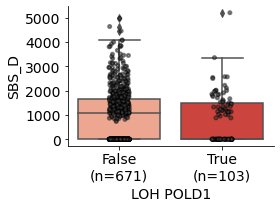

In [23]:
##### PANEL C ######


acts_with_cn['POLD1_loh'] = False
acts_with_cn.loc[pold1_loh.index,'POLD1_loh'] = True

stats.mannwhitneyu(acts_with_cn[acts_with_cn.loc[:,'POLD1_loh']==False].loc[:,'SBS288D'],
                  acts_with_cn[acts_with_cn.loc[:,'POLD1_loh']==True].loc[:,'SBS288D'])

fig,ax = plt.subplots(figsize=(4,3))


for_ns = pd.Series(Counter(acts_with_cn.loc[:,'POLD1_loh'].astype(str)))
acts_with_cn.loc[:,'POLD1_loh'] = acts_with_cn.loc[:,'POLD1_loh'].astype(str) + '\n(n=' + for_ns.loc[acts_with_cn.loc[:,'POLD1_loh'].astype(str)].astype(str).values + ')'



sns.boxplot(data=acts_with_cn,
           x='POLD1_loh',y='SBS288D',palette='Reds')

sns.stripplot(data=acts_with_cn,
           x='POLD1_loh',y='SBS288D',color='grey',edgecolor='black',linewidth=2,
             s=3,alpha=.5)





plt.ylabel('SBS_D')
plt.xlabel('LOH POLD1')

for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# plt.savefig('plots_for_paper/LOH_POLD1.png',dpi=300)


stats.mannwhitneyu(acts_with_cn[acts_with_cn.loc[:,'POLD1_loh'].str.contains('False')].loc[:,'SBS288D'],
                  acts_with_cn[acts_with_cn.loc[:,'POLD1_loh'].str.contains('True')].loc[:,'SBS288D'])

In [24]:
for_ns = pd.Series(Counter(acts_with_cn.loc[:,'POLD1_loh'].astype(str)))
acts_with_cn.loc[:,'POLD1_loh'].astype(str) + '\n(n=' + for_ns.loc[acts_with_cn.loc[:,'POLD1_loh'].astype(str)].astype(str).values + ')'


PD43385a    False\n(n=671)\n(n=671)
PD47039a    False\n(n=671)\n(n=671)
PD47040a    False\n(n=671)\n(n=671)
PD47041a    False\n(n=671)\n(n=671)
PD47042a    False\n(n=671)\n(n=671)
                     ...           
PD57109a    False\n(n=671)\n(n=671)
PD57112a    False\n(n=671)\n(n=671)
PD57113a    False\n(n=671)\n(n=671)
PD57116a    False\n(n=671)\n(n=671)
PD57119a    False\n(n=671)\n(n=671)
Name: POLD1_loh, Length: 774, dtype: object

In [25]:
dna_mismatch_repair_loh = fin_loh_df[fin_loh_df.loc[:,'gene'].isin(to_check)]



from collections import Counter
counts_for_dna_repair = pd.Series(Counter(dna_mismatch_repair_loh.index))

MannwhitneyuResult(statistic=79118.0, pvalue=0.10401175040251126)

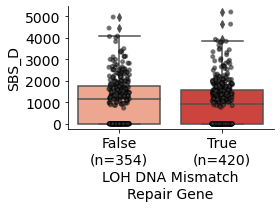

In [26]:
##### PANEL C cont ######


acts_with_cn['DNA_repair_loh'] = 0
acts_with_cn.loc[counts_for_dna_repair.index,'DNA_repair_loh'] = counts_for_dna_repair
acts_with_cn['DNA_repair_loh_binary'] = acts_with_cn.loc[:,'DNA_repair_loh'] > 0

fig,ax = plt.subplots(figsize=(4,3))



for_ns = pd.Series(Counter(acts_with_cn.loc[:,'DNA_repair_loh_binary'].astype(str)))
acts_with_cn.loc[:,'DNA_repair_loh_binary'] = acts_with_cn.loc[:,'DNA_repair_loh_binary'].astype(str) + '\n(n=' + for_ns.loc[acts_with_cn.loc[:,'DNA_repair_loh_binary'].astype(str)].astype(str).values + ')'


sns.boxplot(data=acts_with_cn,
           x='DNA_repair_loh_binary',y='SBS288D',palette='Reds')

sns.stripplot(data=acts_with_cn,
           x='DNA_repair_loh_binary',y='SBS288D',color='grey',edgecolor='black',linewidth=2,
             s=3,alpha=.5)



plt.ylabel('SBS_D')
plt.xlabel('LOH DNA Mismatch\nRepair Gene')

for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# plt.savefig('plots_for_paper/LOH_mismatch_repair.png',dpi=300)

stats.mannwhitneyu(acts_with_cn[acts_with_cn.loc[:,'DNA_repair_loh_binary'].str.contains('False')].loc[:,'SBS288D'],
                  acts_with_cn[acts_with_cn.loc[:,'DNA_repair_loh_binary'].str.contains('True')].loc[:,'SBS288D'])




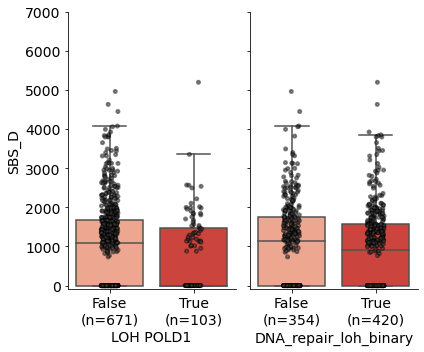

In [27]:
### full panel C ##### 
fig,ax = plt.subplots(1,2,figsize=(6,5),sharey=True)

sns.boxplot(data=acts_with_cn,
           x='POLD1_loh',y='SBS288D',palette='Reds',ax=ax[0],fliersize=0)

sns.stripplot(data=acts_with_cn,
           x='POLD1_loh',y='SBS288D',color='grey',edgecolor='black',linewidth=2,
             s=3,alpha=.5,ax=ax[0])



ax[0].set_ylabel('SBS_D')
ax[0].set_xlabel('LOH POLD1')
ax[0].set_ylim(-100,7000)

for item in ([ax[0].title, ax[0].xaxis.label, ax[0].yaxis.label] +
             ax[0].get_xticklabels() + ax[0].get_yticklabels()):
    item.set_fontsize(14)
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)


##############
sns.boxplot(data=acts_with_cn,
           x='DNA_repair_loh_binary',y='SBS288D',palette='Reds',ax=ax[1],fliersize=0)

sns.stripplot(data=acts_with_cn,
           x='DNA_repair_loh_binary',y='SBS288D',color='grey',edgecolor='black',linewidth=2,
             s=3,alpha=.5,ax=ax[1])



ax[1].set_ylabel('')
# ax[1].set_xlabel('LOH DNA Mismatch\nRepair Gene')

for item in ([ax[1].title, ax[1].xaxis.label, ax[1].yaxis.label] +
             ax[1].get_xticklabels() + ax[1].get_yticklabels()):
    item.set_fontsize(14)
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
plt.tight_layout()
# plt.savefig('plots_for_paper/LOH_POLD1_mismatch_repair.png',dpi=300)

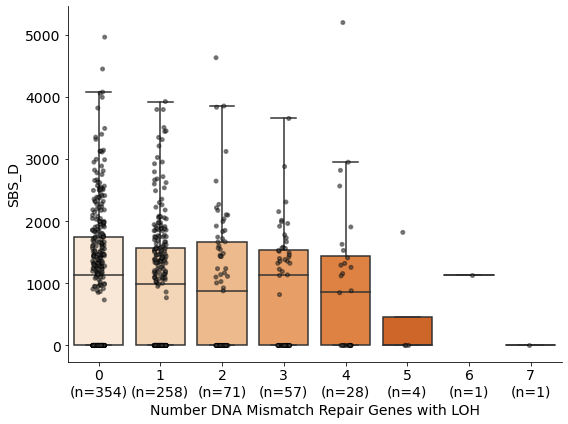

In [28]:
###### Panel D ######



acts_with_cn['DNA_repair_loh'] = 0
acts_with_cn.loc[counts_for_dna_repair.index,'DNA_repair_loh'] = counts_for_dna_repair
acts_with_cn['DNA_repair_loh_binary'] = acts_with_cn.loc[:,'DNA_repair_loh'] > 0


for_ns = pd.Series(Counter(acts_with_cn.loc[:,'DNA_repair_loh'].astype(str)))
acts_with_cn.loc[:,'DNA_repair_loh'] = acts_with_cn.loc[:,'DNA_repair_loh'].astype(str) + '\n(n=' + for_ns.loc[acts_with_cn.loc[:,'DNA_repair_loh'].astype(str)].astype(str).values + ')'



fig,ax = plt.subplots(figsize=(8,6))

sns.boxplot(data=acts_with_cn,
           x='DNA_repair_loh',y='SBS288D',palette='Oranges',fliersize=0)

sns.stripplot(data=acts_with_cn,
           x='DNA_repair_loh',y='SBS288D',color='grey',edgecolor='black',linewidth=2,
             s=3,alpha=.5)

# stats.mannwhitneyu(acts_with_cn[acts_with_cn.loc[:,'DNA_repair_loh_binary']==False].loc[:,'SBS288D'],
#                   acts_with_cn[acts_with_cn.loc[:,'DNA_repair_loh_binary']==True].loc[:,'SBS288D'])


plt.ylabel('SBS_D')
plt.xlabel('Number DNA Mismatch Repair Genes with LOH')

for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# plt.savefig('plots_for_paper/LOH_mismatch_repair.png',dpi=300)